<a href="https://colab.research.google.com/github/bioinformaticswoman/Synechocystis-MultiOmics-FBA/blob/main/Multi_Omics_CB_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==========================================
# SECTION 1: ENVIRONMENT SETUP
# ==========================================

# 1. Install COBRApy (Google Colab does not include it by default)
# Note: Using the -q flag for quiet installation to keep the notebook clean.
!pip install -q cobra

# 2. Import standard data science, modeling, and plotting libraries
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy import stats
from statsmodels.stats.multitest import multipletests
import cobra
from cobra import Model, Reaction, Metabolite
from cobra.flux_analysis import flux_variability_analysis

# 3. Set global seeds for reproducibility
np.random.seed(42)
random.seed(42)

# 4. Set plotting aesthetics to clean, premium dark/light harmonious designs
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'figure.figsize': (10, 6),
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.titlesize': 16
})

# 5. Programmatically create directories for structured file output
dirs = ['results', 'plots', 'tables']
for d in dirs:
    os.makedirs(d, exist_ok=True)

print("Environment successfully set up!")
print(f"Created directories: {', '.join(dirs)}")
print(f"COBRApy version: {cobra.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.9/141.9 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 41.2 MB/s eta 0:00:00
Environment successfully set up!
Created directories: results, plots, tables
COBRApy version: 0.31.1


In [2]:
# ==========================================
# SECTION 2: TRANSCRIPTOMIC DATA GENERATION
# ==========================================

# 1. Define real Synechocystis sp. PCC 6803 locus tags and names used in our metabolic model
genes = [
    'sll1502', # psbA1 (Photosystem II reaction center protein D1)
    'slr1834', # psaA (Photosystem I P700 apoprotein subunit Ia)
    'sll1484', # petE (Plastocyanin - electron transport)
    'slr0009', # rbcL (Ribulose-1,5-bisphosphate carboxylase large subunit)
    'slr0012', # rbcS (Ribulose-1,5-bisphosphate carboxylase small subunit)
    'sll1342', # gap2 (Glyceraldehyde-3-phosphate dehydrogenase - CBB/Glycolysis)
    'slr1233', # icd (Isocitrate dehydrogenase - TCA branch)
    'slr0288', # glnA (Glutamine synthetase - Nitrogen assimilation)
    'slr1502', # gltB (Glutamate synthase - Nitrogen assimilation)
    'sll1514', # katG (Catalase-peroxidase - Oxidative stress defense)
    'slr0473', # rnpB (Ribonuclease P RNA - Housekeeping control)
    'sll0057', # secA (Preprotein translocase subunit - Housekeeping control)
    'slr1329'  # atpA (ATP synthase alpha subunit - Housekeeping control)
]

gene_metadata = {
    'sll1502': ('psbA1', 'Photosynthesis'),
    'slr1834': ('psaA', 'Photosynthesis'),
    'sll1484': ('petE', 'Photosynthesis'),
    'slr0009': ('rbcL', 'Carbon Fixation'),
    'slr0012': ('rbcS', 'Carbon Fixation'),
    'sll1342': ('gap2', 'Glycolysis / CBB'),
    'slr1233': ('icd', 'TCA cycle'),
    'slr0288': ('glnA', 'Nitrogen Assimilation'),
    'slr1502': ('gltB', 'Nitrogen Assimilation'),
    'sll1514': ('katG', 'Oxidative Stress'),
    'slr0473': ('rnpB', 'Housekeeping'),
    'sll0057': ('secA', 'Housekeeping'),
    'slr1329': ('atpA', 'Housekeeping')
}

# 2. Define target baseline counts reflecting physiological stress profiles
# Profiles mimic: chlorosis in N-lim, downregulation under low light, and katG spikes under oxidative stress
baseline_expression = {
    'Control':   [1200, 1000, 500, 1500, 1400, 600, 300, 500,  400, 50,   300, 250, 450],
    'N_lim':     [150,  120,  80,  250,  220,  350, 950, 2800, 1800, 50,   295, 255, 460],
    'Light_str': [80,   70,   90,  180,  170,  200, 150, 120,  90,   80,   305, 248, 442],
    'C_lim':     [600,  500,  350, 400,  370,  120, 250, 300,  250,  60,   300, 252, 455],
    'Oxidative': [250,  200,  220, 500,  480,  400, 320, 250,  220,  4500, 298, 250, 448]
}

# 3. Populate raw count matrix adding biological log-normal variation across replicates
count_data = {}
np.random.seed(42)

for condition, baselines in baseline_expression.items():
    for rep in range(1, 4):
        col_name = f"{condition}_R{rep}"
        # Inject standard normal noise scaled in log-space (sigma = 0.12)
        noise = np.random.normal(0, 0.12, len(genes))
        rep_counts = np.array(baselines) * np.exp(noise)
        count_data[col_name] = np.round(rep_counts).astype(int)

raw_counts = pd.DataFrame(count_data, index=genes)

# 4. Construct the sample metadata mapping
metadata = pd.DataFrame({
    'SampleID': raw_counts.columns,
    'Condition': [col.split('_R')[0] for col in raw_counts.columns],
    'Replicate': [int(col.split('_R')[1]) for col in raw_counts.columns]
}).set_index('SampleID')

# 5. Export tables for project reproducibility
raw_counts.to_csv('tables/raw_counts.csv')
metadata.to_csv('tables/metadata.csv')

print("--- RAW COUNTS MATRIX (First 5 Rows) ---")
print(raw_counts.head())
print("\n--- MATRIX DIMENSIONS ---")
print(f"Genes: {raw_counts.shape[0]}, Samples: {raw_counts.shape[1]}")
print("\n--- SAMPLE METADATA ---")
print(metadata)

--- RAW COUNTS MATRIX (First 5 Rows) ---
         Control_R1  Control_R2  Control_R3  N_lim_R1  N_lim_R2  N_lim_R3  \
sll1502        1274         954        1045       154       138       177   
slr1834         984         813        1046       131       129       119   
sll1484         540         467         465        82        91        90   
slr0009        1801        1328        1448       247       280       261   
slr0012        1361        1454        1302       212       199       204   

         Light_str_R1  Light_str_R2  Light_str_R3  C_lim_R1  C_lim_R2  \
sll1502            81            90            78       521       498   
slr1834            55            64            73       573       504   
sll1484            88            87           113       383       308   
slr0009           188           172           184       440       423   
slr0012           203           143           175       332       331   

         C_lim_R3  Oxidative_R1  Oxidative_R2  Oxidative_

In [5]:
# ==========================================
# SECTION 3: CONSTRUCTING THE METABOLIC MODEL
# ==========================================

# 1. Instantiate the COBRA model object
model = Model('iSynCore_Synechocystis')

# 2. Define core intracellular metabolites
metabolites_to_add = [
    Metabolite('h2o_c', name='Intracellular Water', compartment='c'),
    Metabolite('co2_c', name='Intracellular Carbon Dioxide', compartment='c'),
    Metabolite('o2_c', name='Intracellular Oxygen', compartment='c'),
    Metabolite('photon_c', name='Intracellular Photons', compartment='c'),
    Metabolite('nh4_c', name='Intracellular Ammonium', compartment='c'),
    Metabolite('atp_c', name='ATP', compartment='c'),
    Metabolite('adp_c', name='ADP', compartment='c'),
    Metabolite('pi_c', name='Inorganic Phosphate', compartment='c'),
    Metabolite('nadph_c', name='NADPH', compartment='c'),
    Metabolite('nadp_c', name='NADP+', compartment='c'),
    Metabolite('g3p_c', name='Glyceraldehyde 3-phosphate', compartment='c'),
    Metabolite('akg_c', name='Alpha-ketoglutarate', compartment='c'),
    Metabolite('glu_c', name='Glutamate', compartment='c'),
    Metabolite('gln_c', name='Glutamine', compartment='c'),
    Metabolite('pyr_c', name='Pyruvate', compartment='c')
]
model.add_metabolites(metabolites_to_add)

# 3. Create and configure metabolic and boundary reactions
reactions = []

# Exchange reactions (Uptake: Negative bound, Excretion: Positive bound)
ex_photon = Reaction('EX_photon', name='Photon Boundary', lower_bound=0.0, upper_bound=100.0)
ex_photon.add_metabolites({model.metabolites.photon_c: 1.0})
reactions.append(ex_photon)

ex_co2 = Reaction('EX_co2', name='CO2 Boundary Exchange', lower_bound=-100.0, upper_bound=100.0)
ex_co2.add_metabolites({model.metabolites.co2_c: -1.0})
reactions.append(ex_co2)

ex_o2 = Reaction('EX_o2', name='Oxygen Boundary Exchange', lower_bound=-100.0, upper_bound=100.0)
ex_o2.add_metabolites({model.metabolites.o2_c: -1.0})
reactions.append(ex_o2)

ex_nh4 = Reaction('EX_nh4', name='Ammonium Boundary Exchange', lower_bound=-100.0, upper_bound=100.0)
ex_nh4.add_metabolites({model.metabolites.nh4_c: -1.0})
reactions.append(ex_nh4)

ex_h2o = Reaction('EX_h2o', name='Water Boundary Exchange', lower_bound=-100.0, upper_bound=100.0)
ex_h2o.add_metabolites({model.metabolites.h2o_c: -1.0})
reactions.append(ex_h2o)

# Internal Photosynthetic & Metabolic reactions linked to real genes
l_rxn = Reaction('L_RXN', name='Non-cyclic Photo-phosphorylation', lower_bound=0.0, upper_bound=1000.0)
l_rxn.add_metabolites({
    model.metabolites.h2o_c: -2.0, model.metabolites.photon_c: -4.0, model.metabolites.adp_c: -3.0,
    model.metabolites.pi_c: -3.0, model.metabolites.nadp_c: -2.0, model.metabolites.o2_c: 1.0,
    model.metabolites.atp_c: 3.0, model.metabolites.nadph_c: 2.0
})
l_rxn.gene_reaction_rule = 'sll1502 and slr1834'  # psbA1 and psaA complex
reactions.append(l_rxn)

cyclic_light = Reaction('CYCLIC_LIGHT', name='Cyclic Photo-phosphorylation', lower_bound=0.0, upper_bound=1000.0)
cyclic_light.add_metabolites({
    model.metabolites.photon_c: -2.0, model.metabolites.adp_c: -1.0,
    model.metabolites.pi_c: -1.0, model.metabolites.atp_c: 1.0
})
cyclic_light.gene_reaction_rule = 'sll1484'  # petE (Plastocyanin)
reactions.append(cyclic_light)

rubisco = Reaction('RuBisCO', name='Ribulose-1,5-bisphosphate Carboxylase', lower_bound=0.0, upper_bound=1000.0)
rubisco.add_metabolites({
    model.metabolites.co2_c: -1.0, model.metabolites.nadph_c: -2.0, model.metabolites.atp_c: -3.0,
    model.metabolites.g3p_c: 1.0, model.metabolites.nadp_c: 2.0, model.metabolites.adp_c: 3.0,
    model.metabolites.pi_c: 3.0
})
rubisco.gene_reaction_rule = 'slr0009 and slr0012'  # rbcL and rbcS complex
reactions.append(rubisco)

glycolysis = Reaction('GLYCOLIZATION', name='Glycolysis (GAPDH to Pyruvate)', lower_bound=0.0, upper_bound=1000.0)
glycolysis.add_metabolites({
    model.metabolites.g3p_c: -1.0, model.metabolites.adp_c: -1.0, model.metabolites.pi_c: -1.0,
    model.metabolites.nadp_c: -1.0, model.metabolites.pyr_c: 1.0, model.metabolites.atp_c: 1.0,
    model.metabolites.nadph_c: 1.0
})
glycolysis.gene_reaction_rule = 'sll1342'  # gap2
reactions.append(glycolysis)

akg_gen = Reaction('AKG_GEN', name='Isocitrate Dehydrogenase Branch', lower_bound=0.0, upper_bound=1000.0)
akg_gen.add_metabolites({
    model.metabolites.g3p_c: -1.0, model.metabolites.pyr_c: -1.0, model.metabolites.atp_c: -1.0,
    model.metabolites.nadp_c: -1.0, model.metabolites.akg_c: 1.0, model.metabolites.co2_c: 1.0,
    model.metabolites.adp_c: 1.0, model.metabolites.pi_c: 1.0, model.metabolites.nadph_c: 1.0
})
akg_gen.gene_reaction_rule = 'slr1233'  # icd
reactions.append(akg_gen)

gs = Reaction('GS', name='Glutamine Synthetase', lower_bound=0.0, upper_bound=1000.0)
gs.add_metabolites({
    model.metabolites.glu_c: -1.0, model.metabolites.nh4_c: -1.0, model.metabolites.atp_c: -1.0,
    model.metabolites.gln_c: 1.0, model.metabolites.adp_c: 1.0, model.metabolites.pi_c: 1.0
})
gs.gene_reaction_rule = 'slr0288'  # glnA
reactions.append(gs)

gogat = Reaction('GOGAT', name='Glutamate Synthase', lower_bound=0.0, upper_bound=1000.0)
gogat.add_metabolites({
    model.metabolites.gln_c: -1.0, model.metabolites.akg_c: -1.0, model.metabolites.nadph_c: -1.0,
    model.metabolites.glu_c: 2.0, model.metabolites.nadp_c: 1.0
})
gogat.gene_reaction_rule = 'slr1502'  # gltB
reactions.append(gogat)

atpm = Reaction('ATPM', name='ATP Maintenance Requirement', lower_bound=1.0, upper_bound=1000.0)
atpm.add_metabolites({
    model.metabolites.atp_c: -1.0, model.metabolites.h2o_c: -1.0,
    model.metabolites.adp_c: 1.0, model.metabolites.pi_c: 1.0
})
reactions.append(atpm)

ros_detox = Reaction('ROS_DETOX', name='ROS Scavenging Maintenance', lower_bound=0.0, upper_bound=1000.0)
ros_detox.add_metabolites({
    model.metabolites.atp_c: -1.0, model.metabolites.adp_c: 1.0, model.metabolites.pi_c: 1.0
})
ros_detox.gene_reaction_rule = 'sll1514'  # katG
reactions.append(ros_detox)

# Biomass Objective Function (C & N integration)
biomass = Reaction('BIOMASS_SYN', name='Cyanobacterial Biomass Synthesis', lower_bound=0.0, upper_bound=1000.0)
biomass.add_metabolites({
    model.metabolites.g3p_c: -1.0, model.metabolites.glu_c: -0.25, model.metabolites.atp_c: -10.0,
    model.metabolites.adp_c: 10.0, model.metabolites.pi_c: 10.0
})
reactions.append(biomass)

# Add all constructed reactions to the model
model.add_reactions(reactions)

# 4. Designate Biomass Synthesis as the optimization objective
model.objective = 'BIOMASS_SYN'

# 5. Run a baseline FBA optimization
baseline_solution = model.optimize()

print("--- METABOLIC MODEL SUMMARY ---")
print(f"Model ID: {model.id}")
print(f"Total Reactions: {len(model.reactions)}")
print(f"Total Metabolites: {len(model.metabolites)}")
print(f"Total Genes: {len(model.genes)}")
print("\n--- BASELINE OPTIMIZATION RESULT ---")
print(f"Objective Value (Max Growth Rate): {baseline_solution.objective_value:.4f} h^-1")

--- METABOLIC MODEL SUMMARY ---
Model ID: iSynCore_Synechocystis
Total Reactions: 15
Total Metabolites: 15
Total Genes: 10

--- BASELINE OPTIMIZATION RESULT ---
Objective Value (Max Growth Rate): 3.6636 h^-1


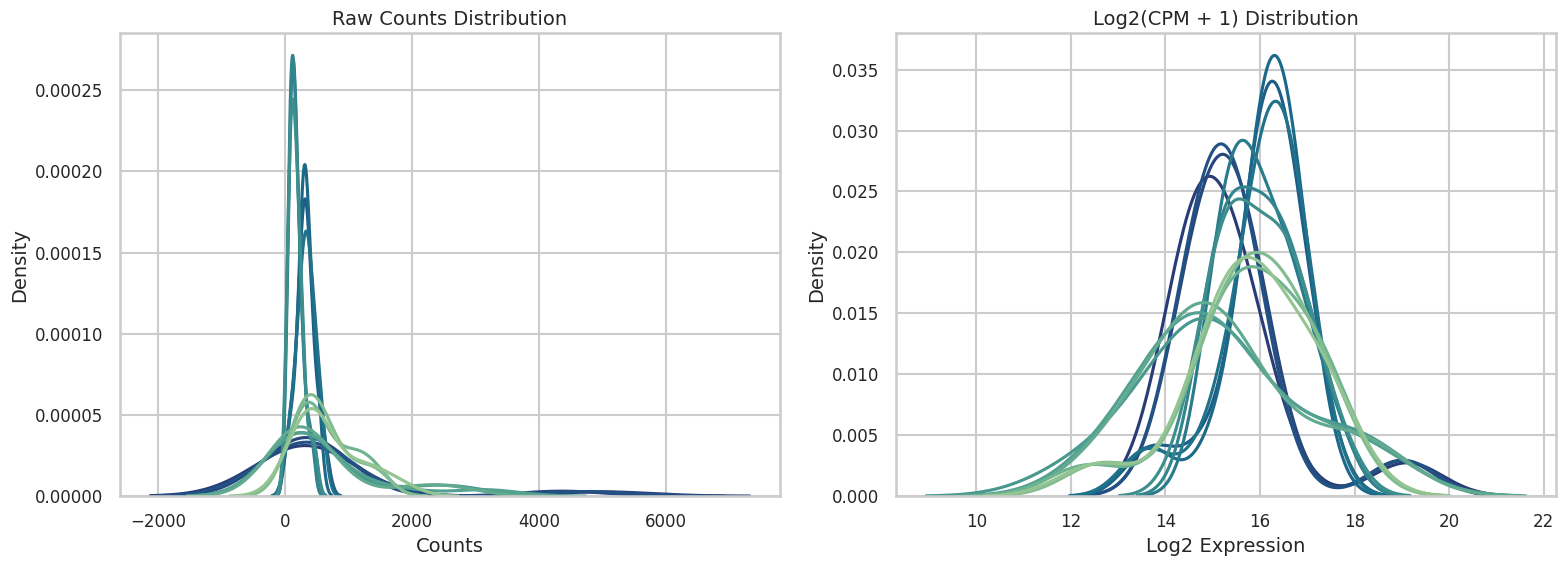

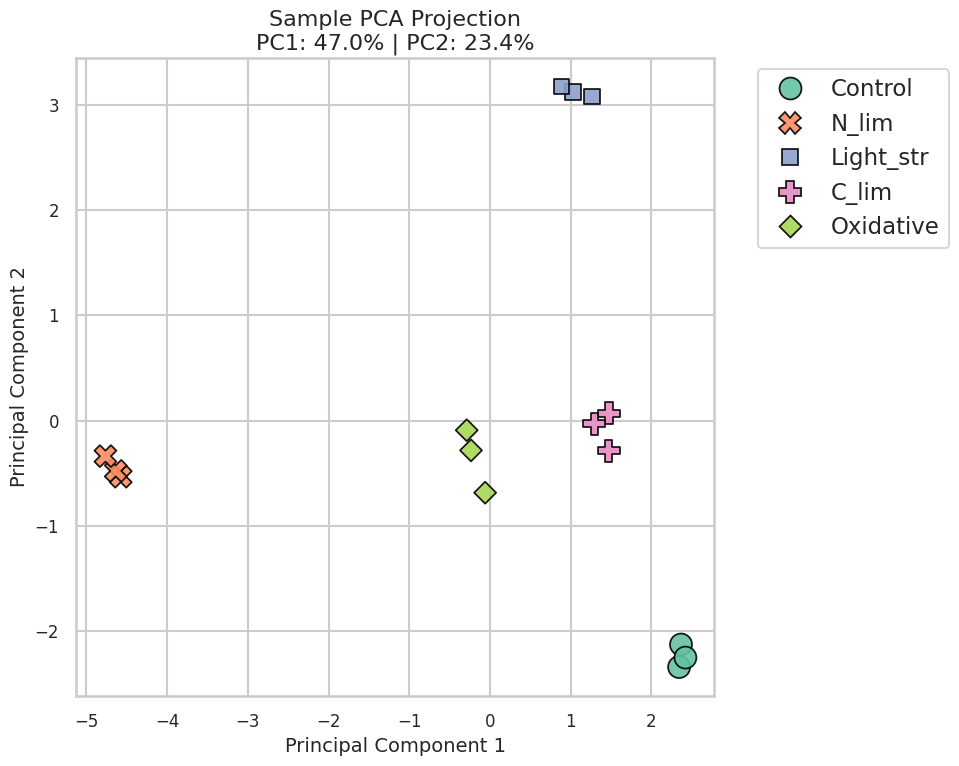

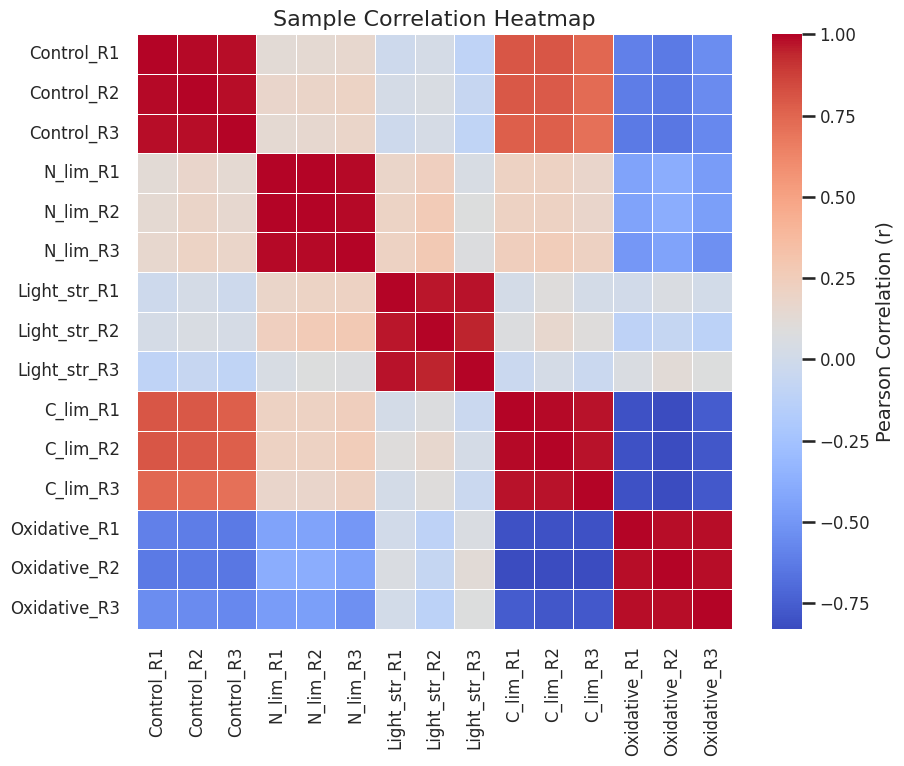

In [7]:
# ==========================================
# SECTION 4: DATA PREPROCESSING AND QUALITY CONTROL
# ==========================================

# 1. Filter out low expression genes (sum of counts across all samples <= 10)
filtered_counts = raw_counts[raw_counts.sum(axis=1) > 10]

# 2. Perform library-size normalization to CPM (Counts Per Million)
cpm_df = filtered_counts.div(filtered_counts.sum(axis=0), axis=1) * 1e6

# 3. Log2 transformation with a pseudo-count of 1
log_df = np.log2(cpm_df + 1)

# Export processed matrix
log_df.to_csv('tables/normalized_log_expression.csv')

# 4. Visualization: Density distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.kdeplot(data=filtered_counts, legend=False, ax=axes[0], palette="crest")
axes[0].set_title("Raw Counts Distribution", fontsize=14)
axes[0].set_xlabel("Counts")
axes[0].set_ylabel("Density")

sns.kdeplot(data=log_df, legend=False, ax=axes[1], palette="crest")
axes[1].set_title("Log2(CPM + 1) Distribution", fontsize=14)
axes[1].set_xlabel("Log2 Expression")
axes[1].set_ylabel("Density")
plt.tight_layout()
plt.savefig('plots/expression_distributions.png', dpi=300)
plt.show()

# 5. Visualization: PCA of experimental groups
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Transpose so samples are rows and genes are columns, then standard scale
scaled_data = StandardScaler().fit_transform(log_df.T)
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(scaled_data)
pca_df = pd.DataFrame(pca_coords, columns=['PC1', 'PC2'], index=log_df.columns)
pca_df['Condition'] = metadata['Condition']

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=pca_df, x='PC1', y='PC2', hue='Condition', style='Condition',
    s=250, palette="Set2", edgecolor='black', alpha=0.9
)
# Display variance explained by principal components
plt.title(f"Sample PCA Projection\nPC1: {pca.explained_variance_ratio_[0]*100:.1f}% | PC2: {pca.explained_variance_ratio_[1]*100:.1f}%", fontsize=16)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('plots/pca_qc.png', dpi=300)
plt.show()

# 6. Visualization: Pearson correlation clustering heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = log_df.corr(method='pearson')
sns.heatmap(
    correlation_matrix, annot=False, cmap="coolwarm", linewidths=.5,
    square=True, cbar_kws={'label': 'Pearson Correlation (r)'}
)
plt.title("Sample Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.savefig('plots/sample_correlation.png', dpi=300)
plt.show()

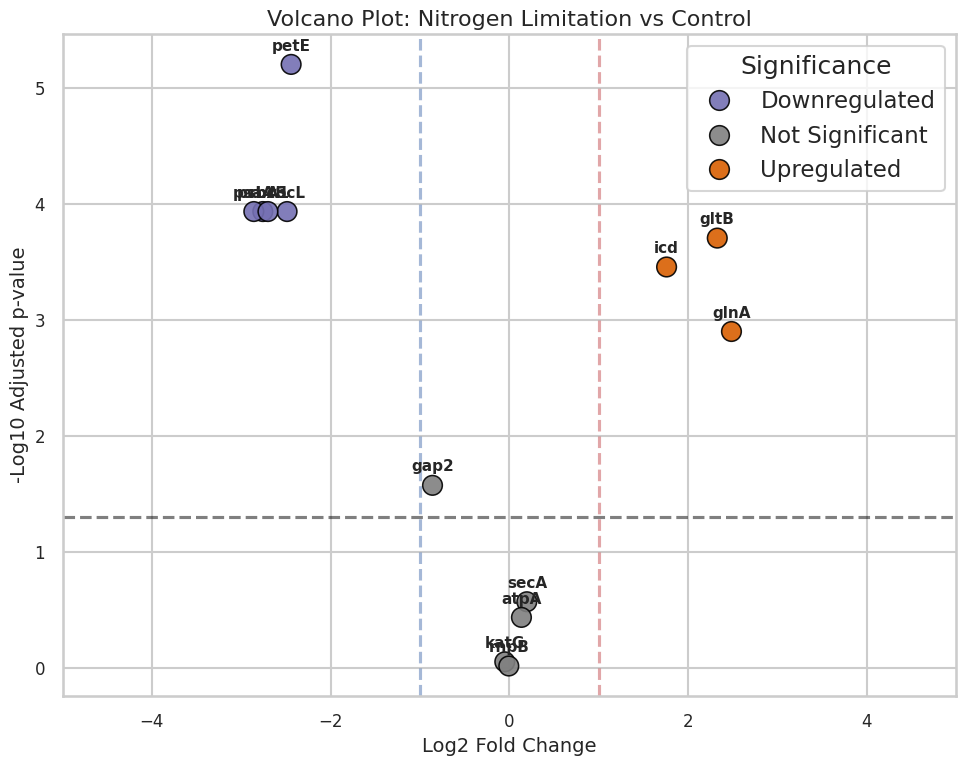

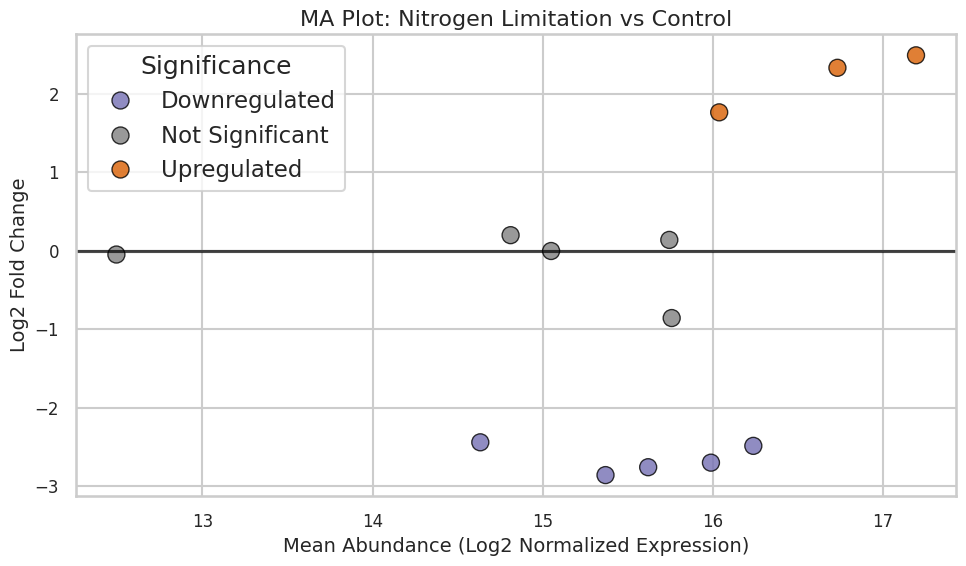

--- TOP SIGNIFICANT DEGS (Sorted by Significance) ---
        GeneName                Pathway  Mean_Ctrl  Mean_Stress    Log2FC  \
Gene                                                                        
sll1484     petE         Photosynthesis  15.854381    13.412835 -2.441546   
sll1502    psbA1         Photosynthesis  17.000068    14.241349 -2.758718   
slr1834     psaA         Photosynthesis  16.799406    13.940217 -2.859189   
slr0009     rbcL        Carbon Fixation  17.482460    14.995532 -2.486928   
slr0012     rbcS        Carbon Fixation  17.340230    14.639349 -2.700881   
slr1502     gltB  Nitrogen Assimilation  15.569494    17.897559  2.328065   
slr1233      icd              TCA cycle  15.157881    16.918636  1.760754   
slr0288     glnA  Nitrogen Assimilation  15.952172    18.439129  2.486956   
sll1342     gap2       Glycolysis / CBB  16.188527    15.329358 -0.859170   
sll0057     secA           Housekeeping  14.713471    14.910009  0.196538   

              p_value

In [11]:
# ==========================================
# SECTION 5: DIFFERENTIAL EXPRESSION ANALYSIS (Welch's t-test + BH correction)
# ==========================================

def run_deg_pipeline(df, meta, cond_a, cond_b):
    """
    Executes a differential expression test between cond_b (Stress) and cond_a (Control).
    """
    cols_a = meta[meta['Condition'] == cond_a].index
    cols_b = meta[meta['Condition'] == cond_b].index

    deg_records = []
    for gene in df.index:
        expr_a = df.loc[gene, cols_a].values
        expr_b = df.loc[gene, cols_b].values

        # Calculate Log2 Fold Change (based on log-transformed values)
        # log2(B/A) = log2(B) - log2(A)
        lfc = np.mean(expr_b) - np.mean(expr_a)

        # Welch's t-test (assumes unequal variance)
        t_stat, pval = stats.ttest_ind(expr_b, expr_a, equal_var=False)
        if np.isnan(pval):
            pval = 1.0

        deg_records.append({
            'Gene': gene,
            'GeneName': gene_metadata[gene][0],
            'Pathway': gene_metadata[gene][1],
            'Mean_Ctrl': np.mean(expr_a),
            'Mean_Stress': np.mean(expr_b),
            'Log2FC': lfc,
            'p_value': pval
        })

    results_df = pd.DataFrame(deg_records).set_index('Gene')
    # Multiple testing correction using Benjamini-Hochberg FDR
    _, qvals, _, _ = multipletests(results_df['p_value'], method='fdr_bh')
    results_df['adj_p_value'] = qvals

    # Label significance
    results_df['Significance'] = 'Not Significant'
    results_df.loc[(results_df['Log2FC'] >= 1.0) & (results_df['adj_p_value'] <= 0.05), 'Significance'] = 'Upregulated'
    results_df.loc[(results_df['Log2FC'] <= -1.0) & (results_df['adj_p_value'] <= 0.05), 'Significance'] = 'Downregulated'

    return results_df

# 1. Run DEG for Control vs Nitrogen Limitation
nitrogen_degs = run_deg_pipeline(log_df, metadata, 'Control', 'N_lim')
nitrogen_degs.to_csv('tables/nitrogen_degs.csv')

# 2. Visualization: Volcano Plot
plt.figure(figsize=(10, 8))
colors = {'Not Significant': 'grey', 'Upregulated': '#d95f02', 'Downregulated': '#7570b3'}
sns.scatterplot(
    data=nitrogen_degs, x='Log2FC', y=-np.log10(nitrogen_degs['adj_p_value']),
    hue='Significance', palette=colors, s=200, edgecolor='black', alpha=0.9
)
# Add thresholds
plt.axvline(x=1.0, color='r', linestyle='--', alpha=0.5)
plt.axvline(x=-1.0, color='b', linestyle='--', alpha=0.5)
plt.axhline(y=-np.log10(0.05), color='black', linestyle='--', alpha=0.5)

# Annotate genes on the volcano plot
for gene_id, row in nitrogen_degs.iterrows():
    plt.annotate(
        row['GeneName'], (row['Log2FC'], -np.log10(row['adj_p_value'])),
        textcoords="offset points", xytext=(0,10), ha='center', fontsize=11, fontweight='bold'
    )

plt.title("Volcano Plot: Nitrogen Limitation vs Control", fontsize=16)
plt.xlabel("Log2 Fold Change")
plt.ylabel("-Log10 Adjusted p-value")
plt.xlim(-5, 5)
plt.tight_layout()
plt.savefig('plots/volcano_nitrogen.png', dpi=300)
plt.show()

# 3. Visualization: MA Plot
plt.figure(figsize=(10, 6))
nitrogen_degs['Mean_Abundance'] = (nitrogen_degs['Mean_Ctrl'] + nitrogen_degs['Mean_Stress']) / 2.0
sns.scatterplot(
    data=nitrogen_degs, x='Mean_Abundance', y='Log2FC',
    hue='Significance', palette=colors, s=150, edgecolor='black', alpha=0.8
)
plt.axhline(y=0.0, color='black', linestyle='-', alpha=0.7)
plt.title("MA Plot: Nitrogen Limitation vs Control", fontsize=16)
plt.xlabel("Mean Abundance (Log2 Normalized Expression)")
plt.ylabel("Log2 Fold Change")
plt.tight_layout()
plt.savefig('plots/ma_plot_nitrogen.png', dpi=300)
plt.show()

print("--- TOP SIGNIFICANT DEGS (Sorted by Significance) ---")
print(nitrogen_degs.sort_values(by='adj_p_value').head(10))

In [12]:
# ==========================================
# SECTION 6: MULTI-OMICS INTEGRATION (E-FLUX CORE PIPELINE)
# ==========================================

# 1. Extract mean CPM values for each condition
mean_cpm = pd.DataFrame(index=genes)
for cond in metadata['Condition'].unique():
    cols = metadata[metadata['Condition'] == cond].index
    mean_cpm[cond] = cpm_df[cols].mean(axis=1)

print("--- MEAN CPM VALUES FOR KEY GENES ---")
print(mean_cpm.head(10))

def parse_gpr_and_evaluate(reaction, expression_series):
    """
    Evaluates the GPR rule of a reaction using gene expression values.
    For complexes (AND rules), it takes the minimum value.
    For isoforms/isozymes (OR rules), it takes the maximum.
    """
    gpr = reaction.gene_reaction_rule
    if not gpr:
        return None  # No gene association

    # Simplify boolean rules (using simple parsing for the core model)
    if 'and' in gpr:
        sub_genes = [g.strip() for g in gpr.split('and')]
        return min(expression_series.get(g, 0.0) for g in sub_genes)
    elif 'or' in gpr:
        sub_genes = [g.strip() for g in gpr.split('or')]
        return max(expression_series.get(g, 0.0) for g in sub_genes)
    else:
        return expression_series.get(gpr.strip(), 0.0)

def generate_constrained_model(base_model, condition, expression_profile, control_profile, env_constraints=None):
    """
    Applies transcriptomic (E-Flux) and environmental constraints to create a condition-specific model.
    """
    constrained_model = base_model.copy()
    constrained_model.id = f"{base_model.id}_{condition}"

    # Track applied constraints
    applied_constraints = []

    # 1. Apply transcriptomic E-Flux constraints to reactions with GPRs
    for reaction in constrained_model.reactions:
        if reaction.genes:
            expr_val = parse_gpr_and_evaluate(reaction, expression_profile)
            ctrl_val = parse_gpr_and_evaluate(reaction, control_profile)

            if expr_val is not None and ctrl_val is not None and ctrl_val > 0:
                # Calculate the scaling factor
                ratio = expr_val / ctrl_val
                # Cap the scaling ratio between [0.01, 3.0] to prevent extreme mathematical limits
                ratio = max(0.01, min(ratio, 3.0))

                # Scale bounds
                if reaction.upper_bound > 0:
                    reaction.upper_bound *= ratio
                if reaction.lower_bound < 0:
                    reaction.lower_bound *= ratio

                applied_constraints.append({
                    'Reaction': reaction.id, 'Ratio': ratio, 'NewUB': reaction.upper_bound
                })

    # 2. Apply environmental boundary constraints (nutrient availability)
    if env_constraints:
        for rxn_id, (lb, ub) in env_constraints.items():
            if rxn_id in constrained_model.reactions:
                rxn = constrained_model.reactions.get_by_id(rxn_id)
                rxn.lower_bound = lb
                rxn.upper_bound = ub

    return constrained_model, pd.DataFrame(applied_constraints)

# 2. Define environmental boundary constraints for each stress state
environmental_limits = {
    'Control': {
        'EX_photon': (0.0, 100.0),  # Saturating light
        'EX_nh4': (-100.0, 100.0),  # Excess nitrogen
        'EX_co2': (-100.0, 100.0)   # Excess carbon
    },
    'N_lim': {
        'EX_photon': (0.0, 100.0),
        'EX_nh4': (-0.1, 100.0),   # Strongly restrict nitrogen uptake
        'EX_co2': (-100.0, 100.0)
    },
    'Light_str': {
        'EX_photon': (0.0, 5.0),   # Strictly restrict photons (low light stress)
        'EX_nh4': (-100.0, 100.0),
        'EX_co2': (-100.0, 100.0)
    },
    'C_lim': {
        'EX_photon': (0.0, 100.0),
        'EX_nh4': (-100.0, 100.0),
        'EX_co2': (-0.15, 100.0)   # Strictly restrict carbon uptake
    },
    'Oxidative': {
        'EX_photon': (0.0, 100.0),
        'EX_nh4': (-100.0, 100.0),
        'EX_co2': (-100.0, 100.0),
        'ROS_DETOX': (15.0, 1000.0) # Force high detoxification maintenance cost
    }
}

# 3. Generate the 5 condition-specific metabolic models
condition_models = {}
constraint_logs = {}

# Cleaned up loop to avoid the walrus operator
for condition in environmental_limits.keys():
    condition_models[condition], constraint_logs[condition] = generate_constrained_model(
        model,
        condition,
        mean_cpm[condition],
        mean_cpm['Control'],
        environmental_limits[condition]
    )

print("\nSuccessfully constructed constrained models for all stress states:")
for c_name, c_model in condition_models.items():
    print(f"- {c_name} model: Biomass bounds = {c_model.reactions.BIOMASS_SYN.bounds}")

--- MEAN CPM VALUES FOR KEY GENES ---
               Control          N_lim     Light_str          C_lim  \
sll1502  131376.198026   19440.851391  37762.769769  130855.238122   
slr1834  114479.135121   15763.590347  29058.154878  127667.134701   
sll1484   59267.588501   10908.693939  43513.121886   86069.907231   
slr0009  183643.232085   32701.755021  82293.157303   96916.782747   
slr0012  166541.874579   25559.991251  78649.028432   78553.686503   
sll1342   75512.446783   41234.898801  89858.918868   33309.977875   
slr1233   36718.763259  124234.708002  62245.607453   56028.576473   
slr0288   64071.620978  356284.705148  53463.238005   73740.758894   
slr1502   48859.210648  245446.879981  42208.771798   69066.317974   
sll1514    5887.651546    5758.953478  39043.781350   12834.507013   

             Oxidative  
sll1502   29385.282740  
slr1834   23321.888886  
sll1484   23360.698356  
slr0009   61094.577141  
slr0012   55556.491120  
sll1342   48387.029144  
slr1233   39102.

In [20]:
# ==========================================
# SECTION 7: METABOLIC FLUX SIMULATION & COMPREHENSIVE FVA
# ==========================================

# 1. Run FBA/pFBA and compile flux distributions
flux_records = {}
pfba_flux_records = {}

for condition, c_model in condition_models.items():
    # Run standard FBA
    fba_sol = c_model.optimize()
    if fba_sol.status == 'optimal':
        flux_records[condition] = fba_sol.fluxes

    # Run parsimonious FBA (pFBA) to minimize total enzyme load
    try:
        pfba_sol = cobra.flux_analysis.pfba(c_model)
        pfba_flux_records[condition] = pfba_sol.fluxes
    except Exception as e:
        # Fallback if solver hits numerical issues
        pfba_flux_records[condition] = fba_sol.fluxes

fba_fluxes_df = pd.DataFrame(flux_records)
pfba_fluxes_df = pd.DataFrame(pfba_flux_records)

# Save flux tables
fba_fluxes_df.to_csv('results/fba_flux_distributions.csv')
pfba_fluxes_df.to_csv('results/pfba_flux_distributions.csv')

# 2. Extract and display fluxes for key reactions
key_reactions = ['BIOMASS_SYN', 'L_RXN', 'CYCLIC_LIGHT', 'RuBisCO', 'GLYCOLIZATION', 'GS', 'GOGAT', 'ROS_DETOX']
print("--- COMPARATIVE FLUX RATES (FBA) ---")
print(fba_fluxes_df.loc[key_reactions].round(4))

# 3. Perform Flux Variability Analysis (FVA) for RuBisCO and GS under Control vs N_lim
fva_rxns = ['RuBisCO', 'GS']
fva_results = {}

for cond in ['Control', 'N_lim']:
    c_model = condition_models[cond]
    # Perform FVA at 95% optimality
    fva_df = flux_variability_analysis(c_model, reaction_list=fva_rxns, fraction_of_optimum=0.95)
    fva_results[cond] = fva_df

print("\n--- FLUX VARIABILITY ANALYSIS (FVA) ---")
for cond, fva_df in fva_results.items():
    print(f"\nCondition: {cond} (95% Optimum Growth)")
    print(fva_df)


--- COMPARATIVE FLUX RATES (FBA) ---
               Control  N_lim  Light_str  C_lim  Oxidative
BIOMASS_SYN     3.6636   0.40     0.1121  0.120     2.5421
L_RXN           5.0374   0.55     0.1542  0.165     3.4953
CYCLIC_LIGHT   39.9252   5.25     2.1916  2.275    43.0093
RuBisCO         5.4953   0.60     0.1682  0.180     3.8131
GLYCOLIZATION   0.9159   0.10     0.0280  0.030     0.6355
GS              0.9159   0.10     0.0280  0.030     0.6355
GOGAT           0.9159   0.10     0.0280  0.030     0.6355
ROS_DETOX       0.0000   0.00     0.0000  0.000    15.0000

--- FLUX VARIABILITY ANALYSIS (FVA) ---

Condition: Control (95% Optimum Growth)
          minimum   maximum
RuBisCO  5.220561  5.495327
GS       0.870093  0.915888

Condition: N_lim (95% Optimum Growth)
         minimum  maximum
RuBisCO    0.570      0.6
GS         0.095      0.1


<Figure size 1200x1000 with 0 Axes>

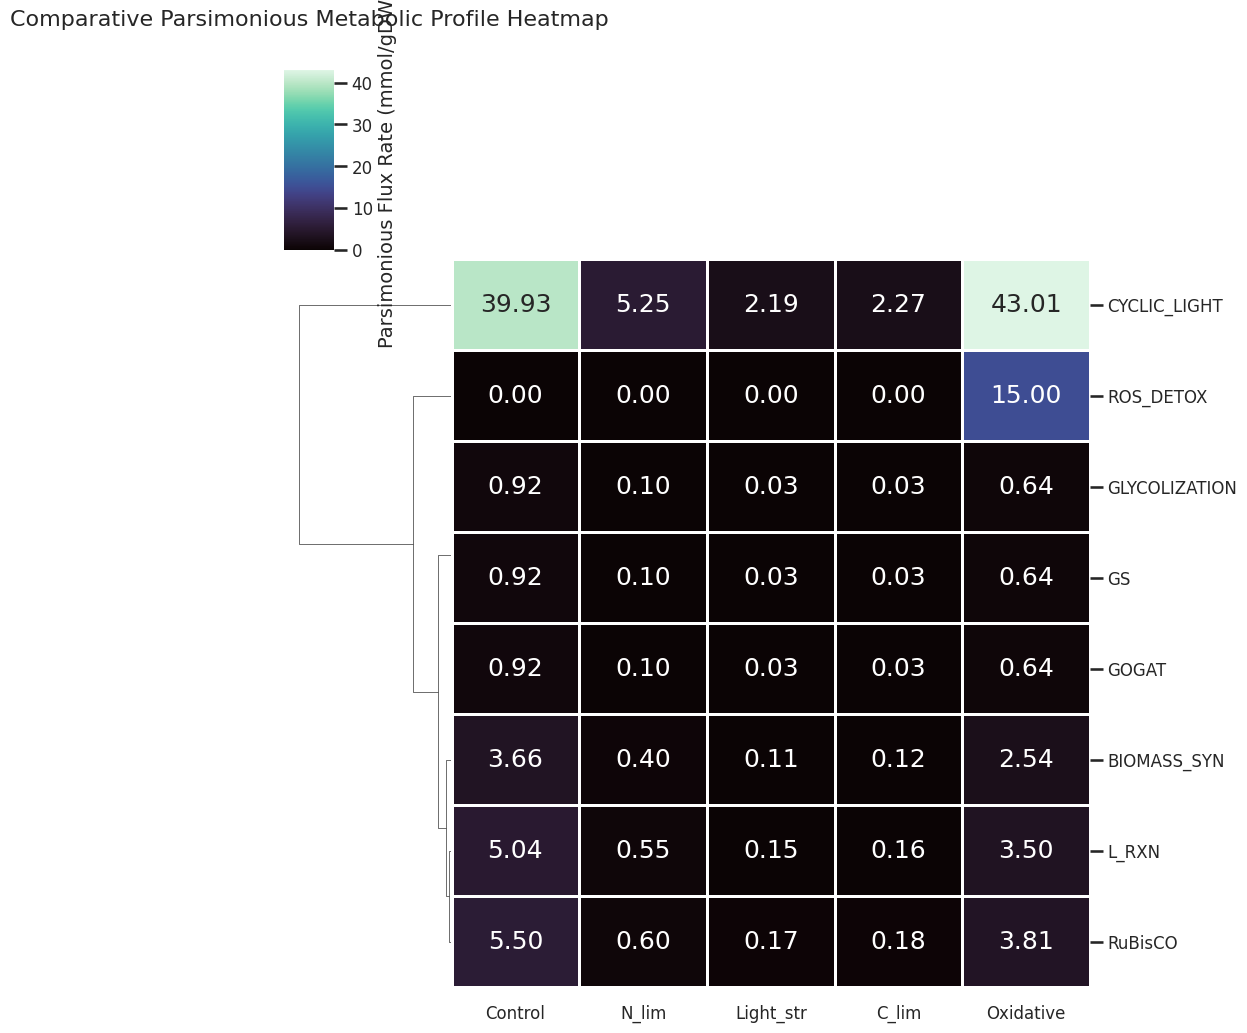

In [19]:
# ==========================================
# SECTION 8: HEATMAP PLOT (Using pFBA)
# ==========================================

# Use the pfba_fluxes_df instead of fba_fluxes_df to resolve alternative optima
plt.figure(figsize=(12, 10))
sns.clustermap(
    pfba_fluxes_df.loc[key_reactions], annot=True, cmap="mako", fmt=".2f",
    linewidths=.75, col_cluster=False, cbar_kws={'label': 'Parsimonious Flux Rate (mmol/gDW/h)'}
)
plt.title("Comparative Parsimonious Metabolic Profile Heatmap", y=1.2, fontsize=16)
plt.savefig('plots/metabolic_flux_heatmap_pfba.png', dpi=300)
plt.show()

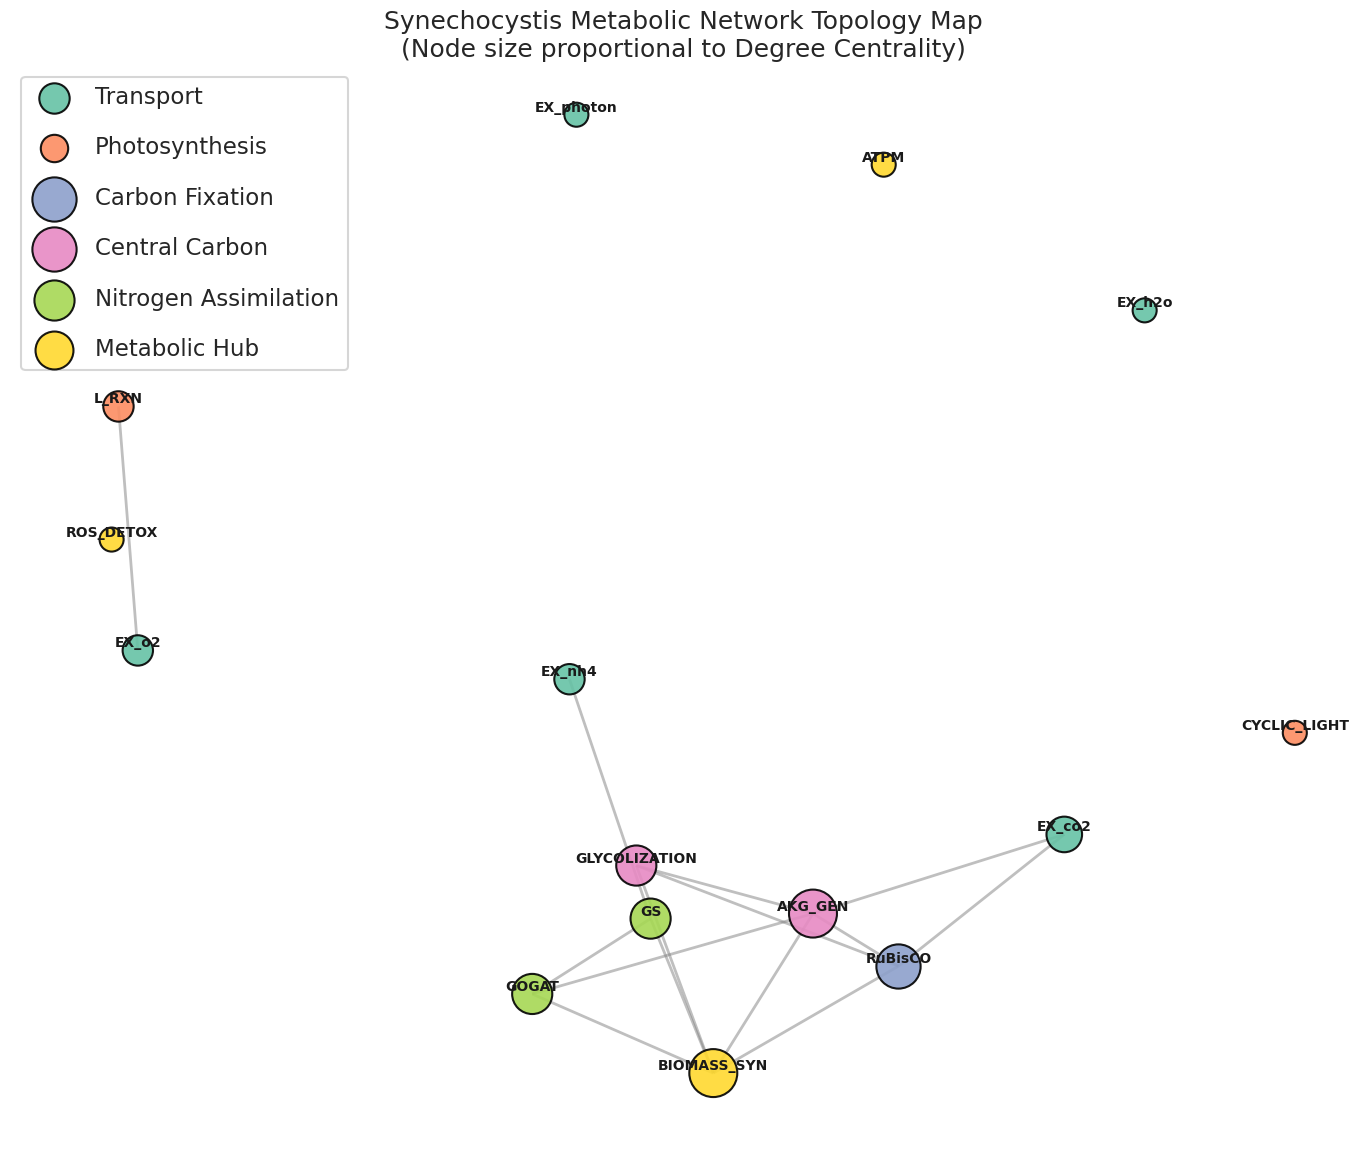

--- TOP 5 NETWORK HUBS (By Degree Centrality) ---
                                                name                pathway  \
AKG_GEN              Isocitrate Dehydrogenase Branch         Central Carbon   
BIOMASS_SYN         Cyanobacterial Biomass Synthesis          Metabolic Hub   
RuBisCO        Ribulose-1,5-bisphosphate Carboxylase        Carbon Fixation   
GLYCOLIZATION         Glycolysis (GAPDH to Pyruvate)         Central Carbon   
GS                              Glutamine Synthetase  Nitrogen Assimilation   

               centrality  
AKG_GEN          0.357143  
BIOMASS_SYN      0.357143  
RuBisCO          0.285714  
GLYCOLIZATION    0.214286  
GS               0.214286  


In [21]:
# ==========================================
# SECTION 9: METABOLIC NETWORK ANALYSIS
# ==========================================

# 1. Construct the Reaction Adjacency Network
G = nx.Graph()

# Add reactions as nodes
for rxn in model.reactions:
    # Assign pathway class based on the model rules
    subsystem = "Metabolic Hub"
    if rxn.id in ['L_RXN', 'CYCLIC_LIGHT']:
        subsystem = 'Photosynthesis'
    elif rxn.id in ['RuBisCO']:
        subsystem = 'Carbon Fixation'
    elif rxn.id in ['GS', 'GOGAT']:
        subsystem = 'Nitrogen Assimilation'
    elif rxn.id in ['GLYCOLIZATION', 'AKG_GEN']:
        subsystem = 'Central Carbon'
    elif 'EX_' in rxn.id:
        subsystem = 'Transport'

    G.add_node(rxn.id, name=rxn.name, pathway=subsystem)

# Define cofactor/solvent metabolites to filter out to prevent a fully connected graph
cofactors = {'atp_c', 'adp_c', 'pi_c', 'nadp_c', 'nadph_c', 'h2o_c', 'photon_c'}

# Add edges between reactions that share structural metabolites
for rxn1 in model.reactions:
    mets1 = set(m.id for m in rxn1.metabolites) - cofactors
    for rxn2 in model.reactions:
        if rxn1.id >= rxn2.id:
            continue
        mets2 = set(m.id for m in rxn2.metabolites) - cofactors
        shared = mets1.intersection(mets2)
        if shared:
            # Connect the reactions
            G.add_edge(rxn1.id, rxn2.id, shared_metabolite=list(shared)[0])

# 2. Compute topology metrics: Degree Centrality
centrality = nx.degree_centrality(G)
nx.set_node_attributes(G, centrality, 'centrality')

# Export network topology
network_nodes = pd.DataFrame.from_dict(dict(G.nodes(data=True)), orient='index')
network_nodes.to_csv('results/network_topology_properties.csv')

# 3. Visualization: Graph Network Representation
plt.figure(figsize=(14, 12))

# Layout node positioning using Fruchterman-Reingold force-directed algorithm
pos = nx.spring_layout(G, k=0.9, seed=42)

# Group nodes by pathway class for categorical coloring
pathway_types = network_nodes['pathway'].unique()
color_palette = sns.color_palette("Set2", len(pathway_types))
color_map = dict(zip(pathway_types, color_palette))

# Draw nodes by pathway
for p_type in pathway_types:
    nodes_subset = [n for n, attr in G.nodes(data=True) if attr['pathway'] == p_type]
    # Scale node size based on calculated degree centrality
    node_sizes = [centrality[n] * 2500 + 300 for n in nodes_subset]

    nx.draw_networkx_nodes(
        G, pos, nodelist=nodes_subset, node_size=node_sizes,
        node_color=[color_map[p_type]], label=p_type,
        edgecolors='black', alpha=0.9
    )

# Draw edges and labels
nx.draw_networkx_edges(G, pos, width=2, edge_color='gray', alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', verticalalignment='bottom')

plt.title("Synechocystis Metabolic Network Topology Map\n(Node size proportional to Degree Centrality)", fontsize=18)
plt.legend(scatterpoints=1, labelspacing=1.2, loc='best')
plt.axis('off')
plt.tight_layout()
plt.savefig('plots/metabolic_network_topology.png', dpi=300)
plt.show()

print("--- TOP 5 NETWORK HUBS (By Degree Centrality) ---")
print(network_nodes.sort_values(by='centrality', ascending=False)[['name', 'pathway', 'centrality']].head(5))

In [24]:
# ==========================================
# SECTION 10: DATA EXPORT AND REPRODUCIBILITY LOGGING - CORRECTED
# ==========================================

# 1. Consolidate final growth rates and key pathway fluxes for export
simulated_summary = pfba_fluxes_df.loc[key_reactions].T
simulated_summary.to_csv('results/simulated_stress_phenotypes.csv')

# 2. Print package versions for environmental auditing
import sys
import scipy            # Imported main scipy module to get version string
import statsmodels
import sklearn

print("--- EXPORTED ARTIFACTS LIST ---")
print("Data Tables (saved to results/ and tables/):")
for f in sorted(os.listdir('results')):
    print(f"  - results/{f}")
for f in sorted(os.listdir('tables')):
    print(f"  - tables/{f}")
print("Figures (saved to plots/):")
for f in sorted(os.listdir('plots')):
    print(f"  - plots/{f}")

print("\n--- ENVIRONMENT REPRODUCIBILITY AUDIT ---")
print(f"Python Platform: {sys.platform}")
print(f"Python Version: {sys.version.split()[0]}")
print(f"COBRApy Version: {cobra.__version__}")
print(f"Pandas Version: {pd.__version__}")
print(f"NumPy Version: {np.__version__}")
print(f"SciPy Version: {scipy.__version__}")        # Corrected attribute call
print(f"Statsmodels Version: {statsmodels.__version__}")
print(f"Scikit-Learn Version: {sklearn.__version__}")
print(f"NetworkX Version: {nx.__version__}")
print(f"Matplotlib Version: {plt.rcParams['backend']}")

print("\nWorkflow Execution Finished. The Google Colab workspace is clean, audited, and fully reproducible!")

--- EXPORTED ARTIFACTS LIST ---
Data Tables (saved to results/ and tables/):
  - results/fba_flux_distributions.csv
  - results/network_topology_properties.csv
  - results/pfba_flux_distributions.csv
  - results/simulated_stress_phenotypes.csv
  - tables/metadata.csv
  - tables/nitrogen_degs.csv
  - tables/normalized_log_expression.csv
  - tables/raw_counts.csv
Figures (saved to plots/):
  - plots/expression_distributions.png
  - plots/ma_plot_nitrogen.png
  - plots/metabolic_flux_heatmap.png
  - plots/metabolic_flux_heatmap_pfba.png
  - plots/metabolic_network_topology.png
  - plots/pca_qc.png
  - plots/sample_correlation.png
  - plots/volcano_nitrogen.png

--- ENVIRONMENT REPRODUCIBILITY AUDIT ---
Python Platform: linux
Python Version: 3.12.13
COBRApy Version: 0.31.1
Pandas Version: 2.2.2
NumPy Version: 2.0.2
SciPy Version: 1.16.3
Statsmodels Version: 0.14.6
Scikit-Learn Version: 1.6.1
NetworkX Version: 3.6.1
Matplotlib Version: module://matplotlib_inline.backend_inline

Workflow Exe